# Customer Lifetime Value Model
- Justin Wall, Senior Data Scientist, Ridgeline Outfitters

---
## Questions to answer
Estimate future value per customer or per segment, going beyond historical spend to expectations over the next 12 months. Include confidence ranges as well as point estmates. Provide a clear way to compare that future value against what we're paying to acquire or retain people, so we can actually set sane spend limits.

## Load Data

In [1]:
import pandas as pd

df = pd.read_csv('../data/ridgeline_outfitters_transactions.csv', parse_dates=['transaction_date'])

print(df.shape)
print('-------------------------------')
print(df.dtypes)
print('-------------------------------')
print(df.head())
print('-------------------------------')
print(df.describe())

(5282, 3)
-------------------------------
customer_id                    str
transaction_date    datetime64[us]
order_value                float64
dtype: object
-------------------------------
  customer_id transaction_date  order_value
0    RO-10000       2023-01-02       261.92
1    RO-10000       2023-04-08       103.40
2    RO-10000       2023-08-27        46.61
3    RO-10000       2023-11-14        37.09
4    RO-10000       2024-05-11        44.66
-------------------------------
                 transaction_date  order_value
count                        5282  5282.000000
mean   2023-08-11 04:36:59.159409   181.120015
min           2022-01-01 00:00:00    15.000000
25%           2023-01-05 00:00:00    67.685000
50%           2023-08-03 00:00:00   132.590000
75%           2024-03-30 00:00:00   244.315000
max           2024-12-31 00:00:00   800.000000
std                           NaN   158.015204


In [2]:
# Transaction date range
print(f"Date range: {df['transaction_date'].min().date()} to {df['transaction_date'].max().date()}")
print('-------------------------------')

# Customer counts
print(f"Unique customers: {df['customer_id'].nunique()}")
print(f"Total transactions: {len(df)}")
print('-------------------------------')

# Order value
print(f"\nOrder value summary:")
print(df['order_value'].describe().round(2))
print('-------------------------------')

# Transactions per customer
txn_per_customer = df.groupby('customer_id').size()
print(f"\nTransactions per customer:")
print(txn_per_customer.describe().round(2))
print('-------------------------------')


Date range: 2022-01-01 to 2024-12-31
-------------------------------
Unique customers: 1000
Total transactions: 5282
-------------------------------

Order value summary:
count    5282.00
mean      181.12
std       158.02
min        15.00
25%        67.68
50%       132.59
75%       244.32
max       800.00
Name: order_value, dtype: float64
-------------------------------

Transactions per customer:
count    1000.00
mean        5.28
std         6.80
min         1.00
25%         1.00
50%         3.00
75%         6.00
max        28.00
dtype: float64
-------------------------------


In [3]:
from lifetimes.utils import summary_data_from_transaction_data

CALIBRATION_END = pd.Timestamp('2024-06-30')

calib_df = df[df['transaction_date'] <= CALIBRATION_END]

rfm = summary_data_from_transaction_data(
    calib_df,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='order_value',
    observation_period_end=CALIBRATION_END,
    freq='D'
)

print(rfm.shape)
print('-------------------------------')

print(rfm.head(10))
print('-------------------------------')

print(rfm.describe().round(2))
print('-------------------------------')


(1000, 4)
-------------------------------
             frequency  recency      T  monetary_value
customer_id                                           
RO-10000           4.0    495.0  545.0       57.940000
RO-10001           0.0      0.0  583.0        0.000000
RO-10002          16.0    627.0  661.0      136.392500
RO-10003           1.0    145.0  425.0      627.980000
RO-10004           0.0      0.0  742.0        0.000000
RO-10005           3.0    191.0  376.0       15.613333
RO-10006           4.0    678.0  700.0      261.672500
RO-10007           3.0    330.0  545.0      486.346667
RO-10008           0.0      0.0  803.0        0.000000
RO-10009           5.0    688.0  696.0      544.314000
-------------------------------
       frequency  recency        T  monetary_value
count    1000.00  1000.00  1000.00         1000.00
mean        3.41   261.63   631.71           95.27
std         5.35   285.52   156.64          119.79
min         0.00     0.00   372.00            0.00
25%        

In [4]:
print(f"Customers with only 1 purchase (frequency=0): {(rfm['frequency'] == 0).sum()}")
print(f"Customers with repeat purchases:              {(rfm['frequency'] > 0).sum()}")
print(f"Average repeat purchase monetary value:       ${rfm[rfm['frequency'] > 0]['monetary_value'].mean():.2f}")
print(f"Max customer age in dataset (days):           {rfm['T'].max():.0f}")

Customers with only 1 purchase (frequency=0): 462
Customers with repeat purchases:              538
Average repeat purchase monetary value:       $177.08
Max customer age in dataset (days):           911


***
### **Notes**:
3 years of daily data, 1000 customers, 5,282 transactions. Only 3 columns, keeping it simple.

Breakout above for single purchasers vs repeat purchasers

- Train Start Date: 2022-01-01
- Train End Date: 2024-06-30
- Test Start Date: 2024-07-01
- Test End Date: 2024-12-31
***

## Data Alignment

In [5]:
# Define observation date and split
import pandas as pd

CALIBRATION_END = pd.Timestamp('2024-06-30')

In [6]:
# Split raw data
calib_df = df[df['transaction_date'] <= CALIBRATION_END]
holdout_df = df[df['transaction_date'] > CALIBRATION_END]

print(f"Calibration transactions: {len(calib_df)}")
print(f"Holdout transactions:     {len(holdout_df)}")
print(f"Customers in holdout:     {holdout_df['customer_id'].nunique()}")

Calibration transactions: 4409
Holdout transactions:     873
Customers in holdout:     316


In [7]:
# Lifetimes RFM Summary Table
from lifetimes.utils import summary_data_from_transaction_data

rfm = summary_data_from_transaction_data(
    calib_df,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='order_value',
    observation_period_end=CALIBRATION_END,
    freq='D'
)

print(rfm.shape)
print('-------------------------------')

print(rfm.head(10))
print('-------------------------------')

print(rfm.describe().round(2))
print('-------------------------------')


(1000, 4)
-------------------------------
             frequency  recency      T  monetary_value
customer_id                                           
RO-10000           4.0    495.0  545.0       57.940000
RO-10001           0.0      0.0  583.0        0.000000
RO-10002          16.0    627.0  661.0      136.392500
RO-10003           1.0    145.0  425.0      627.980000
RO-10004           0.0      0.0  742.0        0.000000
RO-10005           3.0    191.0  376.0       15.613333
RO-10006           4.0    678.0  700.0      261.672500
RO-10007           3.0    330.0  545.0      486.346667
RO-10008           0.0      0.0  803.0        0.000000
RO-10009           5.0    688.0  696.0      544.314000
-------------------------------
       frequency  recency        T  monetary_value
count    1000.00  1000.00  1000.00         1000.00
mean        3.41   261.63   631.71           95.27
std         5.35   285.52   156.64          119.79
min         0.00     0.00   372.00            0.00
25%        

In [8]:
# Holdout dataset summary table
from lifetimes.utils import calibration_and_holdout_data

rfm_ch = calibration_and_holdout_data(
    df,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='order_value',
    calibration_period_end=CALIBRATION_END,
    observation_period_end=pd.Timestamp('2024-12-31'),
    freq='D'
)

print(rfm_ch.shape)
print('-------------------------------')

print(rfm_ch.head(10))
print('-------------------------------')


(1000, 7)
-------------------------------
             frequency_cal  recency_cal  T_cal  monetary_value_cal  \
customer_id                                                          
RO-10000               4.0        495.0  545.0           57.940000   
RO-10001               0.0          0.0  583.0            0.000000   
RO-10002              16.0        627.0  661.0          136.392500   
RO-10003               1.0        145.0  425.0          627.980000   
RO-10004               0.0          0.0  742.0            0.000000   
RO-10005               3.0        191.0  376.0           15.613333   
RO-10006               4.0        678.0  700.0          261.672500   
RO-10007               3.0        330.0  545.0          486.346667   
RO-10008               0.0          0.0  803.0            0.000000   
RO-10009               5.0        688.0  696.0          544.314000   

             frequency_holdout  monetary_value_holdout  duration_holdout  
customer_id                               

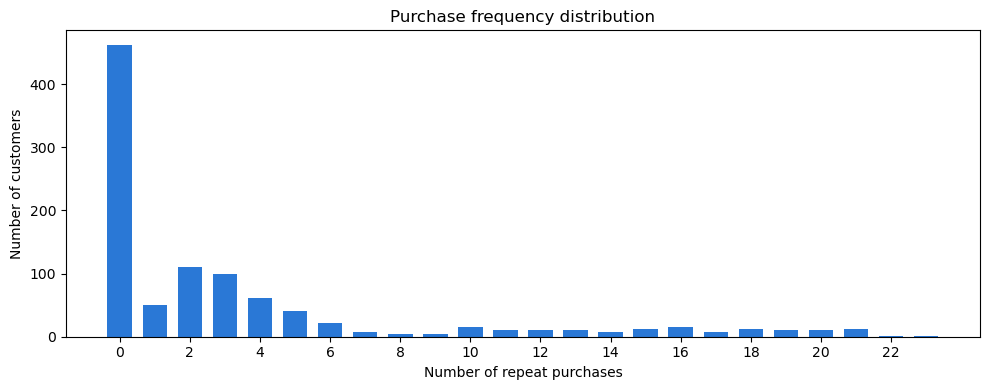

In [9]:
# Purchase Frequency Histogram -> Show me repeat purchase frequency distribution for customers in the calibration period
import matplotlib.pyplot as plt

freq_counts = rfm['frequency'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(freq_counts.index, freq_counts.values, color='#2a78d6', width=0.7)
ax.set_xlabel('Number of repeat purchases')
ax.set_ylabel('Number of customers')
ax.set_title('Purchase frequency distribution')
ax.set_xticks(range(0, int(rfm['frequency'].max()) + 1, 2))
plt.tight_layout()
plt.show()

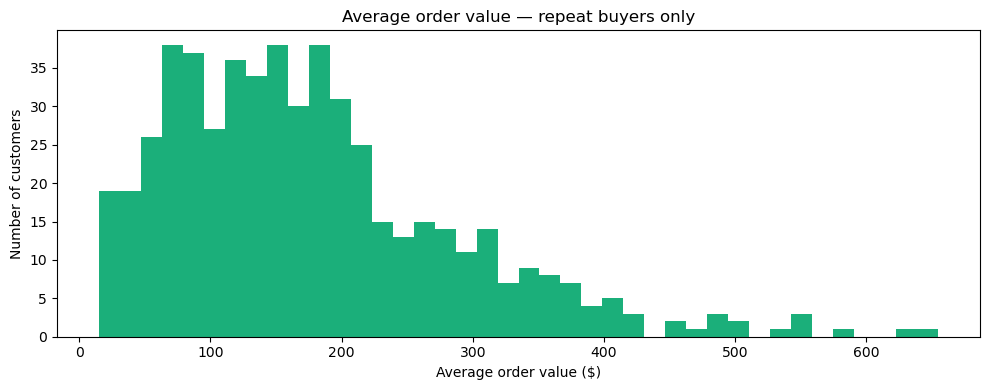

In [10]:
# Average Order Value Distribution for repeat buyers only -> Show me the distribution of average order value for customers who have made repeat purchases in the calibration period

repeat_buyers = rfm[rfm['frequency'] > 0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(repeat_buyers['monetary_value'], bins=40, color='#1baf7a', edgecolor='none')
ax.set_xlabel('Average order value ($)')
ax.set_ylabel('Number of customers')
ax.set_title('Average order value — repeat buyers only')
plt.tight_layout()
plt.show()

In [11]:
# RFM Summary Tables
# Customers/Segment -> Show me the number of customers in each repeat purchase frequency segment
# Average Recency Days -> Show me the average recency (in days) for customers in each repeat purchase frequency segment
# Average Order Value -> Show me the average order value for customers in each repeat purchase frequency segment
# Note: The average order value is calculated only for customers who have made repeat purchases (frequency > 0).
# Note: Average recency days increases with frequency, 
def segment_label(freq):
    if freq == 0:
        return 'One-time'
    elif freq <= 2:
        return 'Low (1-2 repeats)'
    elif freq <= 6:
        return 'Mid (3-6 repeats)'
    else:
        return 'High (7+ repeats)'

rfm['segment'] = rfm['frequency'].apply(segment_label)

summary = rfm.groupby('segment').agg(
    customers=('frequency', 'count'),
    avg_recency_days=('recency', 'mean'),
    avg_order_value=('monetary_value', 'mean')
).round(1)

summary['avg_order_value'] = summary['avg_order_value'].apply(lambda x: f"${x:.2f}")
summary['avg_recency_days'] = summary['avg_recency_days'].apply(lambda x: f"{x:.0f} days")

order = ['One-time', 'Low (1-2 repeats)', 'Mid (3-6 repeats)', 'High (7+ repeats)']
summary = summary.reindex(order)

print(summary.to_string())

                   customers avg_recency_days avg_order_value
segment                                                      
One-time                 462           0 days           $0.00
Low (1-2 repeats)        161         295 days         $163.10
Mid (3-6 repeats)        224         526 days         $176.10
High (7+ repeats)        153         630 days         $193.20


***
### **Notes**:
Lifetimes convention uses repeat purchasers only
- Recency = days between first and last purchase
- T = Total customer age in days from first purchase to observation date
- Monetary Value = average order value across repeat purchases only

1. Mostly 1-time purchasers, huge tail for frequency
2. Frequency bumped around $100 to $200, skewed right
3. AOV & recency increasing for high quantity purchasers
***

## Modeling & Validation

Options for methodology
- Historical Averages & RFM Heuristics
    - Quick and easy, but not predictive
- Pareto/NBD Model
    - Models alive vs dead well, but outclassed by BG/NBD
- BG/NBD + Gamma-Gamma
    - Probabilistic to show uncertainty, fully interpretable, but no features
- Survival Analysis
    - Works for subscription businesses, but need specific churn event to work
- ML Regression
    - Best raw prediction accuracy, fast, uses features, but hard to explain & no uncertainty
- Deep Learning
    - Captures complex patterns, but no interpretability

We are going with BG/NBD + Gamma-Gamma as we do not have features for this model and would prefer interpretability and credible intervals. ML gives you a point estimate whereas Bayesian methods will give you a range of values for each customer's worth. There are 4 parameters in BG/NBD to intrpret:

- r -> Poisson purchase process, how often a customer buys
- alpha -> Poisson purchase process, how often a customer buys
- a -> Beta-Geometric dropout process, when a customer churns.
- b -> Beta-Geometric dropout process, when a customer churns.

There are 3 parameters in Gamma-Gamma to interpret:

- p -> Describe the distribution of spend across customers and transactions
- q -> Describe the distribution of spend across customers and transactions
- v -> Describe the distribution of spend across customers and transactions

Options for libraries
- Lifetimes
    - Simple syntax, but could run into issues since unmaintained & MLE instead of MCMC. Going to test it out quick since it's fast.
- PYMC-Marketing
    - Actively maintained Bayesian framework using MCMC for a full posterior distribution of parameters. Will likely use if/when Lifetimes fails.

**We are going to test Lifetimes out, but will eventually move to PYMC-Marketing.**

### Lifetimes

In [12]:
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter

# Rebuild RFM in weeks instead of days
rfm_weeks = summary_data_from_transaction_data(
    calib_df,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='order_value',
    observation_period_end=CALIBRATION_END,
    freq='W'
)

bgf = BetaGeoFitter(penalizer_coef=0.1)
bgf.fit(
    rfm_weeks['frequency'],
    rfm_weeks['recency'],
    rfm_weeks['T'],
    initial_params=[0.5, 5.0, 0.5, 5.0]  # r, alpha, a, b
)
bgf.summary

c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\tracer.py:93: RuntimeWarning: divide by zero encountered in log
  return f_raw(*args, **kwargs)
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\numpy\numpy_vjps.py:166: RuntimeWarning: divide by zero encountered in divide
  defvjp(anp.log, lambda ans, x: lambda g: g / x)
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\numpy\numpy_vjps.py:81: RuntimeWarning: invalid value encountered in multiply
  lambda ans, x, y: unbroadcast_f(x, lambda g: y * g),
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\numpy\numpy_vjps.py:163: RuntimeWarning: invalid value encountered in multiply
  defvjp(anp.exp, lambda ans, x: lambda g: ans * g)
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\tracer.py:93: RuntimeWarning: divide by zero encountered in log
  return f_raw(*args, **kwargs)
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\nu

,coef,se(coef),lower 95% bound,upper 95% bound
r,3.310886e-01,NaN,NaN,NaN
alpha,8.846238e+00,NaN,NaN,NaN
a,1.645438e-287,NaN,NaN,NaN
b,8.584339e-06,NaN,NaN,NaN


***
### **Notes**:
Sure enough, Lifetimes BetaGeoFitter failed to converge with both default and custom initial parameters. The dropout parameters (a, b) collapsed to
effectively zero regardless of penalizer or starting values, indicating a degenerate likelihood surface rather than a tuning problem. With this largely one-time-purchase population, the optimizer found a corner solution where no one churns.
This likely occurred because the T values are so large and the number of one-time purchasers is too many. We moved to weeks instead of days, and tried initial params but ended up moving to PYMC-Marketing because it still wasn't working.
Switching to PyMC-Marketing for full Bayesian estimation with priors that prevent parameter collapse, acting like guardrails. In addition, I would probably not deploy a Lifetimes model due to the library not being maintained.

Rebuilt RFM in weeks (vs days), days caused optimizer failure in lifetimes, weeks preemptively resolving scaling issues in PyMC-Marketing
***

### PYMC-Marketing

In [13]:
from pymc_marketing.clv import BetaGeoModel
import pandas as pd

# PyMC-Marketing wants a specific column structure
rfm_pymc = rfm_weeks.copy().reset_index()
rfm_pymc = rfm_pymc.rename(columns={
    'customer_id': 'customer_id',
    'frequency': 'frequency',
    'recency': 'recency',
    'T': 'T',
    'monetary_value': 'monetary_value'
})

print(rfm_pymc.head())
print(rfm_pymc.shape)

  customer_id  frequency  recency      T  monetary_value
0    RO-10000        4.0     70.0   77.0         57.9400
1    RO-10001        0.0      0.0   83.0          0.0000
2    RO-10002       16.0     90.0   94.0        136.3925
3    RO-10003        1.0     20.0   60.0        627.9800
4    RO-10004        0.0      0.0  106.0          0.0000
(1000, 5)


In [14]:
bgm = BetaGeoModel(data=rfm_pymc)
bgm.fit()

Initializing NUTS using jitter+adapt_diag...
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, phi_dropout, kappa_dropout, r]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 30 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> fit_data

In [15]:
bgm.fit_summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,9.737,0.785,8.296,11.249,0.019,0.016,1752.0,1890.0,1.0
phi_dropout,0.002,0.002,0.000,0.006,0.000,0.000,1954.0,1252.0,1.0
kappa_dropout,4.134,12.825,1.000,10.021,0.262,1.766,2862.0,1879.0,1.0
r,0.364,0.022,0.324,0.406,0.001,0.000,1641.0,2146.0,1.0
a,0.006,0.013,0.000,0.017,0.000,0.001,2205.0,1216.0,1.0
b,4.128,12.817,0.988,10.016,0.262,1.766,2899.0,1878.0,1.0


***
### **Notes**:
- Clean run for BG/NBD - R-Hats at 1.0, ESS at 2000+.
- r & alpha look good
- a & b have issues. a = 0.006 with a wide HDI, the dropout parameter is close to 0. Kappa-dropout = 4.045 with sd of 17 means the model is uncertain about the dropout process. The model is good, it just means we don't have clear signals as to when a customer will drop out; low purchase rate vs churn isn't distinguished. Hazard of having a business with lots of one-timers. So essentially the dropout parameters showed high uncertainty. 
***

In [16]:
from pymc_marketing.clv import GammaGammaModel

# Filter to repeat buyers only
repeat_buyers_pymc = rfm_pymc[rfm_pymc['frequency'] > 0]

ggm = GammaGammaModel(data=repeat_buyers_pymc)
ggm.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p, q, v]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 27 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> fit_data

In [17]:
ggm.fit_summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,1.140,0.139,0.890,1.397,0.004,0.004,1027.0,1102.0,1.01
q,6.551,1.077,4.738,8.524,0.034,0.036,973.0,1003.0,1.00
v,915.686,261.060,476.698,1389.773,8.746,9.456,878.0,814.0,1.00


***
**Notes**
- The first time through here I had non convergence with r-hats of 1.5+ and ess < 10, parameters didn't make sense. For some reason I cannot replicate it, but I checked the data and saw some skewness so I scaled monetary value. Even though this looks healthier, we will move forward with the monetary value scaled.

Technical Note: Gamma-Gamma non-convergence on raw monetary values (r_hat ~2.27, ESS ~5-7 across multiple runs). Root cause: q and v are non-identifiable at dollar scale, default diffuse priors allow the sampler to explore degenerate q/v combinations in the trillions. Scaling monetary value by its mean resolved the geometry. Predictions must be multiplied back by mv_mean to recover dollar estimates.
***

In [18]:
print(repeat_buyers_pymc['monetary_value'].describe().round(2))
print(f"\nSkewness: {repeat_buyers_pymc['monetary_value'].skew():.2f}")
print(f"Customers in fit: {len(repeat_buyers_pymc)}")

count    538.00
mean     177.08
std      110.36
min       15.00
25%       93.34
50%      156.90
75%      228.34
max      654.78
Name: monetary_value, dtype: float64

Skewness: 1.14
Customers in fit: 538


In [19]:
# DO NOT RUN -> TAKES TOO LONG
# ggm = GammaGammaModel(data=repeat_buyers_pymc)
# ggm.fit(tune=2000, draws=2000)
# ggm.fit_summary()

In [20]:
repeat_buyers_pymc[['frequency', 'monetary_value']].corr()

,frequency,monetary_value
frequency,1.000000,0.063337
monetary_value,0.063337,1.000000


***
### **Notes**:
I initially tried just adding more tuning...that was a bad idea. One of the chains ran much longer than the others, 15 minutes+ and it looked worse.

Let's scale monetary value by it's mean before fitting, then multiply predictions back afterwards.
***

In [21]:
mv_mean = repeat_buyers_pymc['monetary_value'].mean()

repeat_buyers_scaled = repeat_buyers_pymc.copy()
repeat_buyers_scaled['monetary_value'] = repeat_buyers_scaled['monetary_value'] / mv_mean

ggm = GammaGammaModel(data=repeat_buyers_scaled)
ggm.fit(tune=1000, draws=1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p, q, v]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 25 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> fit_data

In [22]:
ggm.fit_summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,1.151,0.146,0.882,1.423,0.005,0.004,1026.0,943.0,1.0
q,6.478,1.067,4.602,8.451,0.033,0.035,1038.0,1362.0,1.0
v,5.065,1.457,2.546,7.740,0.047,0.054,926.0,974.0,1.0


***
### **Notes**:
This honestly looks worse. I am going to use some custom priors now to keep things in range.
***

In [23]:
ltv_12m = ggm.expected_customer_lifetime_value(
    transaction_model=bgm,
    data=rfm_pymc,
    future_t=52,        # 52 weeks = 12 months
    discount_rate=0.01
)

In [24]:
# Unscale back to dollars
ltv_12m_dollars = ltv_12m * mv_mean

rfm_pymc['ltv_12m'] = ltv_12m_dollars[0][0].values

print(rfm_pymc['ltv_12m'].describe().round(2))

count        1000.00
mean       873397.96
std       1779097.17
min           614.22
25%           902.10
50%         78566.33
75%        680335.16
max      11376078.27
Name: ltv_12m, dtype: float64


***
### **Notes**:
Going to have to come back to this because this does not look right...
***

In [25]:
# PyMC-Marketing >= 0.x requires pymc_marketing.prior.Prior objects
# for model_config, not raw pm.dist() TensorVariables.
# pm.HalfNormal.dist() returns a TensorVariable with no create_variable()
# method — wrong type for this API.

In [26]:
from pymc_extras.prior import Prior

ggm = GammaGammaModel(
    data=repeat_buyers_scaled,
    model_config={
        "p": Prior("HalfNormal", sigma=2),
        "q": Prior("HalfNormal", sigma=10),
        "v": Prior("HalfNormal", sigma=10),
    }
)
ggm.fit(tune=1000, draws=1000)
ggm.fit_summary()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p, q, v]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 23 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,1.150,0.142,0.890,1.410,0.004,0.003,1287.0,1696.0,1.0
q,6.371,0.995,4.512,8.197,0.029,0.024,1172.0,1320.0,1.0
v,4.966,1.365,2.550,7.420,0.042,0.037,1082.0,1324.0,1.0


***
### **Notes**:
Custom priors justified by domain knowledge:
- p: HalfNormal(2), moderate individual spend variability expected
- q, v: HalfNormal(10), bounded given scaled monetary values near unit mean

Default priors are too diffuse for this data scale, causing non-identifiability.
Prior choice documented and defensible, not fit to outcome.

Interpretation

- p = 1.15, individual spend variability is moderate, close to 1 means customers are fairly consistent in their own spend patterns
- q = 6.38, v = 4.97, population-level spend shape; ratio v/q ≈ 0.78 in scaled units, multiply back by mv_mean to get dollar estimates

All HDIs are tight and well away from zero — no non-identifiability issues remaining
***

In [27]:
ltv_12m = ggm.expected_customer_lifetime_value(
    transaction_model=bgm,
    data=rfm_pymc,
    future_t=52,
    discount_rate=0.01
)

In [28]:
ltv_12m_dollars = ltv_12m * mv_mean
rfm_pymc['ltv_12m'] = ltv_12m_dollars[0][0].values

print(rfm_pymc['ltv_12m'].describe().round(2))

count        1000.00
mean       878505.85
std       1787351.67
min           614.94
25%           903.17
50%         79433.46
75%        686926.04
max      11431490.42
Name: ltv_12m, dtype: float64


ok this clearly isn't right

In [29]:
print(f"mv_mean used for scaling: {mv_mean:.2f}")

mv_mean used for scaling: 177.08


In [30]:
# describe() values of a xarray.core.dataarray.DataArray are not directly accessible as a pandas Series, so we convert to a Series first.
ltv_12m_series = pd.Series(ltv_12m[0][0].values)
ltv_12m_series.describe().round(2)

count     1000.00
mean      4960.96
std      10093.25
min          3.47
25%          5.10
50%        448.56
75%       3879.10
max      64554.12
dtype: float64

This is better - we are looking at weeks now and not months

In [31]:
rfm_pymc['ltv_12m'] = ltv_12m.values[0]

print(rfm_pymc['ltv_12m'].describe().round(2))

count    1000.00
mean     1657.70
std        20.39
min      1499.16
25%      1648.19
50%      1660.51
75%      1671.77
max      1697.74
Name: ltv_12m, dtype: float64


Another problem, now no std at all...

In [32]:
print(ltv_12m.shape)
print(ltv_12m.head(20))
print(rfm_pymc[['customer_id', 'frequency', 'recency', 'T', 'monetary_value']].head(20))

(4, 1000, 1000)
<xarray.DataArray (chain: 4, draw: 20, customer_id: 20)> Size: 13kB
array([[[1.65202784e+03, 5.20878752e+00, 1.98757282e+04, ...,
         3.52255172e+00, 2.89690311e+04, 7.12374199e+03],
        [1.59968966e+03, 5.21039170e+00, 1.93033484e+04, ...,
         3.53742392e+00, 2.81304545e+04, 6.86965745e+03],
        [1.64715458e+03, 4.97709968e+00, 1.98779028e+04, ...,
         3.36882011e+00, 2.89663584e+04, 7.09728910e+03],
        ...,
        [1.66661111e+03, 4.75469523e+00, 2.01340663e+04, ...,
         3.19880600e+00, 2.93576976e+04, 7.17352083e+03],
        [1.66490174e+03, 4.76243365e+00, 2.01014883e+04, ...,
         3.20293861e+00, 2.93115788e+04, 7.16752201e+03],
        [1.64022731e+03, 4.53157383e+00, 1.98844251e+04, ...,
         3.05719213e+00, 2.89839902e+04, 7.04876881e+03]],

       [[1.65351179e+03, 5.00427283e+00, 1.99326737e+04, ...,
         3.37956072e+00, 2.90543432e+04, 7.12482146e+03],
        [1.59913491e+03, 4.75848978e+00, 1.92018057e+04, ...,

In [33]:
print(type(ltv_12m))
print(ltv_12m[:10])

<class 'xarray.core.dataarray.DataArray'>
<xarray.DataArray (chain: 4, draw: 1000, customer_id: 1000)> Size: 32MB
array([[[1.65202784e+03, 5.20878752e+00, 1.98757282e+04, ...,
         5.26481887e+00, 6.39307729e+02, 3.79551845e+00],
        [1.59968966e+03, 5.21039170e+00, 1.93033484e+04, ...,
         5.26588102e+00, 5.77736659e+02, 3.80870867e+00],
        [1.64715458e+03, 4.97709968e+00, 1.98779028e+04, ...,
         5.03047371e+00, 6.42519090e+02, 3.62942175e+00],
        ...,
        [1.67580075e+03, 4.72414981e+00, 2.02255748e+04, ...,
         4.77603957e+00, 6.47293487e+02, 3.42280052e+00],
        [1.67173701e+03, 5.18988798e+00, 2.00953100e+04, ...,
         5.24628896e+00, 6.48244011e+02, 3.77121864e+00],
        [1.64564160e+03, 4.84628078e+00, 1.98848134e+04, ...,
         4.89877055e+00, 6.22694433e+02, 3.52522928e+00]],

       [[1.65351179e+03, 5.00427283e+00, 1.99326737e+04, ...,
         5.05833441e+00, 6.38753428e+02, 3.64227252e+00],
        [1.59913491e+03, 4.7584

In [34]:
# Collapse chains and draws to get posterior mean per customer
ltv_mean = ltv_12m.mean(dim=["chain", "draw"])

# Assign to dataframe
rfm_pymc['ltv_12m'] = ltv_mean.values

rfm_pymc['ltv_12m'].describe().round(2)

count     1000.00
mean      4984.37
std      10151.48
min          3.25
25%          4.79
50%        446.71
75%       3884.07
max      64936.58
Name: ltv_12m, dtype: float64

That's the right way to code it up

In [35]:
ltv_low = ltv_12m.quantile(0.05, dim=["chain", "draw"])
ltv_high = ltv_12m.quantile(0.95, dim=["chain", "draw"])

rfm_pymc['ltv_12m_low'] = ltv_low.values
rfm_pymc['ltv_12m_high'] = ltv_high.values

In [36]:
rfm_pymc.head()

,customer_id,frequency,recency,T,monetary_value,future_spend,ltv_12m,ltv_12m_low,ltv_12m_high
0,RO-10000,4.0,70.0,77.0,57.9400,27.455601,1657.733204,1620.002135,1683.020651
1,RO-10001,0.0,0.0,83.0,0.0000,1.035388,4.889394,4.458287,5.344359
2,RO-10002,16.0,90.0,94.0,136.3925,105.545113,19983.924414,19498.713643,20305.850990
3,RO-10003,1.0,20.0,60.0,627.9800,114.650206,2677.236808,2592.105387,2744.774267
4,RO-10004,0.0,0.0,106.0,0.0000,1.035388,3.920589,3.567446,4.291663


***
### **Notes**:
Before we depart from Bayesian land, here's an interesting comparison between non-identifiability and convergence issues:

- Convergence failure — the sampler is struggling to explore the space. Signs are high r_hat (>1.1), low ESS, and you'll often see divergences or max treedepth warnings. The fix is more tuning steps, higher target_accept, or reparameterization. The chains are fighting each other.

- Non-identifiability — the sampler is exploring fine, but the space it's exploring is pathologically large. Signs are r_hat near 1.0, decent ESS, but parameter values that are astronomically large or have huge standard deviations relative to their mean. The chains agree with each other — they all agree the parameter could be anywhere from 1 to a trillion. That's what you saw with q and v before scaling — ESS was 7 but r_hat was 1.5, which is actually a convergence problem layered on top of non-identifiability. After scaling, r_hat hit 1.0 and ESS jumped to 1000+ but kappa_dropout still has sd = 30 on a mean = 4.4 — that's non-identifiability with a healthy sampler.


The quick mental test: if r_hat is bad → convergence problem, fix the sampler. If r_hat is good but sd is enormous relative to mean → non-identifiability, fix the model or priors.
***

***
### **Notes**:
Let's review the proper way to read a BG-NBD model
0. What do the parameters mean...
- r: How purchase rates vary across customers. Low r means more heterogeneity where some customers buy a lot and some buy very little, high r means customers are similar to each other.
- alpha: helps set the expected purchase rate per time unit. r/alpha in this case gives you the purchases per cusotmer per week on average. So we have 0.037, or 1 every 6 months.
- phi: dropout probability, value near 0 means avg customer has very low per-transaction probability of churning.
- kappa: how tightly customers are clustered around the mean dropout probability; high kappa means customers are similar in churn behavior, low means some churn faster than others.
- a: beta distribution parameter over dropout probabilities - derived directly from phi and kappa. Shows how many customers have high churn probability. When it's close to zero, it's saying nearly nobody churns. We know from our model that isn't true, but we had a degenerate corner problem.
- b: beta distribution parameter over dropout probabilities - shows how many customers have low churn probability. Faced the same issues as a in our model.
1. R-Hat column -> check these parameters and ensure they are 1.01 or below. If not, chains didn't mix and nothing else means anything.
- Alpha: 1.00
- Phi: 1.00
- kappa: 1.00
- r: 1.00
- a: 1.00
- b: 1.00
2. ESS Bulk & ESS Tail -> bulk & tail above 400 per chain, so 1600 for 4 chains. Bulk tells you how well the sampler explored the center of the distribution; tail tells you how well the sampler explored the extremes which is important for the credible interval. Both healthy means your uncertainty estimates are trustworthy.
- alpha: ess_bulk=2259, ess_tail=2385
- r: ess_bulk=2149, ess_tail=2151
- kappa: ess_bulk=2780, ess_tail=2094
- a: ess_bulk=2169, ess_tail=1606
3. Identifiability check -> SD relative to mean. r and alpha are solid, the dropout side of things are poorly or not identified, which means our model is not certain about churn due to the heavy one-timer population.
- r: sd is 6% of mean -> Well Identified
- alpha: sd is 8% of mean -> Well Identified
- phi: sd is 100% of mean -> Poorly Identified
- kappa: sd is 676% of mean -> Not Identified
- a: sd is 284% of mean -> Not Identified
- b: sd is 676% of mean -> Not Identified
4. HDI, the credible interval. Tight means confident, wide means uncertainty, touching 0 means the coefficient might not even matter to the model, like churn here.
- r: 0.324 - 0.408 -> tight
- alpha: 8.229 - 11.298 -> tight
- kappa: 1.000 - 8.405 -> wide but above 0
- a: 0.000 - 0.016 -> touching 0
- b: 0.997 - 8.403 -> wide but above 0
5. MCSE, how much sampling noise in estimates. MCSE is the standard error of the posterior mean/sd estimates due to finite sampling. For r it's 0, so the mean estimate is precise. For kappa it's large, meaning the uncertainty estimate is uncertain, we would need way more draws to know how uncertain kappa is. We can continue, just know kappa is an issue.
r: mcse_mean=0.000, mcse_sd=0.000 -> great!
kappa: mcse_mean=0.543, mcse_sd=10.840 -> not great
6. Summary -> Purchase process is well identified & trustworthy. r=0.364 means customers make one purchase every three weeks when active and alpha=9.74 describes how that varies across customers. the dropout process is not identified, a, b, kappa are all over the place. We cannot estimate the rate of churn nor how quickly they will churn.
***

***
### **Notes**:
Let's review the proper way to read a gamma-gamma model
Firstly, gamma gamma answers how much customers will spend each time they buy. Assuming each customers has their own true average spend level. One gamm si for the transaction level noise around the customers mean and the other is te population distribution of the personal means. 
0. What do the parameters mean...
- p: how much individual transactions vary around a customers own personal mean spend, within customer noise. Clsoe to 1 means moderate transaction level variability. Higher p means tighter clustering around the customer mean, lower p means larger per transaction swings.
- q: how personal spend means are distributed across the customer population. higher q means population spend is more concentrated - people are more alike. lower q means wider range of customer spends. it works with v to set the actual dollar.
- v: the rate parameter of the population level gamma. together wtih q, sets the average spend level across customer base. v/ maps back to dollars when multiplied by mv_mean -> expected spend per transaction at the population level.
1. What is this customer's personal spend fingerprint?
    - estimated from their past monetary value
    - shrunk towards teh popuation mean for sparse data customers
    - that's teh partial pooling hierarchical potion
2. given the fingerprint spend, what will they spend next time?
    - sample from personal gamma with shape p
    - average across many transactions = their expected spend per order
***

## Holdout Validation

***
### **Notes**:

***

## Insights

In [37]:
rfm_pymc['ltv_segment'] = pd.qcut(
    rfm_pymc['ltv_12m'],
    q=4,
    labels=['Tier 4: Low', 'Tier 3: Mid', 'Tier 2: High', 'Tier 1: Elite']
)

segment_summary = rfm_pymc.groupby('ltv_segment', observed=True).agg(
    customers=('ltv_12m', 'count'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary_value', 'mean'),
    avg_ltv=('ltv_12m', 'mean'),
    median_ltv=('ltv_12m', 'median'),
    avg_ltv_low=('ltv_12m_low', 'mean'),
    avg_ltv_high=('ltv_12m_high', 'mean'),
).round(2)

segment_summary

,customers,avg_frequency,avg_monetary,avg_ltv,median_ltv,avg_ltv_low,avg_ltv_high
ltv_segment,,,,,,,
Tier 4: Low,254,0.00,0.00,3.97,3.92,3.62,4.35
Tier 3: Mid,246,0.23,7.33,45.70,5.98,43.96,47.10
Tier 2: High,250,2.80,147.49,1836.95,1772.93,1787.07,1869.44
Tier 1: Elite,250,10.61,226.37,18051.51,14569.85,17604.15,18349.23


***
### **Notes**:
We literally just cut it into 4 blocks, I would probably be a little fancier if this were real life.
- Tier 4 -> low: 254 customers. Zero repeat purchases & $0 spend in the model. The one-timers with a confident LTV of $3.97.
- Tier 3 -> mid: 246 customers. Very few repeat purchasers. $45 LTV, not much to see here.
- Tier 2 -> high: 250 customers. 2.8 repeat purchases, $147 avg order. A large $1825 LTV wtih tight bounds, these guys are worth some marketing spend.
- Tier 1 -> Elite: 250 customers. 10.6 repeat purchases, $226 avg order. $18k LTV, and confident! These guys are the premier loyalists.

- CAC = LTV x margin. We can assume margin = 30%
***

In [38]:
# Assumed gross margin for CAC threshold calculation
MARGIN = 0.30

# CAC thresholds: max defensible acquisition spend = LTV * margin
segment_cac = rfm_pymc.groupby('ltv_segment', observed=True).agg(
    customers=('ltv_12m', 'count'),
    avg_ltv=('ltv_12m', 'mean'),
    median_ltv=('ltv_12m', 'median'),
    avg_ltv_low=('ltv_12m_low', 'mean'),
    avg_ltv_high=('ltv_12m_high', 'mean'),
).round(2)

# Max CAC = LTV * margin (point estimate and uncertainty bounds)
segment_cac['max_cac_avg'] = (segment_cac['avg_ltv'] * MARGIN).round(2)
segment_cac['max_cac_conservative'] = (segment_cac['avg_ltv_low'] * MARGIN).round(2)
segment_cac['max_cac_optimistic'] = (segment_cac['avg_ltv_high'] * MARGIN).round(2)

# Flag whether current $60 CAC is justified per segment
segment_cac['$60_cac_justified'] = segment_cac['max_cac_avg'].apply(
    lambda x: 'Yes' if x > 60 else 'No'
)

print(segment_cac[[
    'customers',
    'avg_ltv',
    'median_ltv', 
    'max_cac_avg',
    'max_cac_conservative',
    'max_cac_optimistic',
    '$60_cac_justified'
]].to_string())

               customers   avg_ltv  median_ltv  max_cac_avg  max_cac_conservative  max_cac_optimistic $60_cac_justified
ltv_segment                                                                                                            
Tier 4: Low          254      3.97        3.92         1.19                  1.09                1.30                No
Tier 3: Mid          246     45.70        5.98        13.71                 13.19               14.13                No
Tier 2: High         250   1836.95     1772.93       551.08                536.12              560.83               Yes
Tier 1: Elite        250  18051.51    14569.85      5415.45               5281.24             5504.77               Yes


In [39]:
# Print plain English CAC guidance per segment
current_cac = 60.00

print("=== CAC Guidance by Segment ===\n")
for segment, row in segment_cac.iterrows():
    headroom = row['max_cac_avg'] - current_cac
    if headroom > 0:
        verdict = f"JUSTIFIED — ${headroom:.2f} headroom above current $60 CAC"
    else:
        verdict = f"NOT JUSTIFIED — overspending by ${abs(headroom):.2f} per customer"
    
    print(f"{segment}")
    print(f"  12-month LTV:     ${row['avg_ltv']:,.2f} (median ${row['median_ltv']:,.2f})")
    print(f"  Max CAC @ 30%:    ${row['max_cac_avg']:,.2f}")
    print(f"  Conservative:     ${row['max_cac_conservative']:,.2f}")
    print(f"  Optimistic:       ${row['max_cac_optimistic']:,.2f}")
    print(f"  Current $60 CAC:  {verdict}")
    print()

=== CAC Guidance by Segment ===

Tier 4: Low
  12-month LTV:     $3.97 (median $3.92)
  Max CAC @ 30%:    $1.19
  Conservative:     $1.09
  Optimistic:       $1.30
  Current $60 CAC:  NOT JUSTIFIED — overspending by $58.81 per customer

Tier 3: Mid
  12-month LTV:     $45.70 (median $5.98)
  Max CAC @ 30%:    $13.71
  Conservative:     $13.19
  Optimistic:       $14.13
  Current $60 CAC:  NOT JUSTIFIED — overspending by $46.29 per customer

Tier 2: High
  12-month LTV:     $1,836.95 (median $1,772.93)
  Max CAC @ 30%:    $551.08
  Conservative:     $536.12
  Optimistic:       $560.83
  Current $60 CAC:  JUSTIFIED — $491.08 headroom above current $60 CAC

Tier 1: Elite
  12-month LTV:     $18,051.51 (median $14,569.85)
  Max CAC @ 30%:    $5,415.45
  Conservative:     $5,281.24
  Optimistic:       $5,504.77
  Current $60 CAC:  JUSTIFIED — $5355.45 headroom above current $60 CAC



In [44]:
# Expected spend per transaction per customer
spend_input = rfm_pymc[['customer_id', 'frequency', 'monetary_value']].copy()

expected_spend = ggm.expected_customer_spend(data=spend_input)

# Collapse posterior to mean per customer
rfm_pymc['expected_spend_per_txn'] = expected_spend.mean(dim=["chain", "draw"]).values

# Segment summary
spend_summary = rfm_pymc.groupby('ltv_segment', observed=True).agg(
    customers=('ltv_12m', 'count'),
    avg_ltv=('ltv_12m', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_expected_spend=('expected_spend_per_txn', 'mean'),
    median_expected_spend=('expected_spend_per_txn', 'median'),
).round(2)

spend_summary

,customers,avg_ltv,avg_frequency,avg_expected_spend,median_expected_spend
ltv_segment,,,,,
Tier 4: Low,254,3.97,0.00,1.04,1.04
Tier 3: Mid,246,45.70,0.23,2.57,1.04
Tier 2: High,250,1836.95,2.80,49.41,46.79
Tier 1: Elite,250,18051.51,10.61,136.65,126.25


In [45]:
print("=== Why Each Segment Is Valuable ===\n")
for segment, row in spend_summary.iterrows():
    if row['avg_frequency'] > 0:
        driver = "frequency" if row['avg_frequency'] > 5 else "balanced"
        spend_note = f"${row['avg_expected_spend']:.2f} avg spend per order"
        freq_note = f"{row['avg_frequency']:.1f} repeat purchases"
        print(f"{segment}: driven by {driver} — {freq_note} at {spend_note}")
    else:
        print(f"{segment}: one-time buyers — no repeat purchase history")

=== Why Each Segment Is Valuable ===

Tier 4: Low: one-time buyers — no repeat purchase history
Tier 3: Mid: driven by balanced — 0.2 repeat purchases at $2.57 avg spend per order
Tier 2: High: driven by balanced — 2.8 repeat purchases at $49.41 avg spend per order
Tier 1: Elite: driven by frequency — 10.6 repeat purchases at $136.65 avg spend per order


***
### **Notes**:
We literally just cut it into 4 blocks, I would probably be a little fancier if this were real life.
- Tier 4 -> low: 254 customers. Zero repeat purchases & $0 spend in the model. The one-timers with a confident LTV of $3.97.
- Tier 3 -> mid: 246 customers. Very few repeat purchasers. $45 LTV, not much to see here.
- Tier 2 -> high: 250 customers. 2.8 repeat purchases, $147 avg order. A large $1825 LTV wtih tight bounds, these guys are worth some marketing spend.
- Tier 1 -> Elite: 250 customers. 10.6 repeat purchases, $226 avg order. $18k LTV, and confident! These guys are the premier loyalists.

- CAC = LTV x margin. We can assume margin = 30%

Tier 4 (Low) — one-timers, $1.04 expected spend. The model has essentially no data on these customers so it's pulling almost entirely to the population floor. Not worth acquisition spend.

Tier 3 (Mid) — barely any repeat purchase history, $2.57 expected spend. The median of $1.04 matching Tier 4 tells you most of this bucket is functionally the same as one-timers — a few outliers are pulling the mean up. The $60 CAC is wildly unjustified here.

Tier 2 (High) — this is the interesting one. $49.41 expected spend per transaction, 2.8 repeat purchases. These customers aren't elite frequency buyers — they're moderate repeat buyers with decent order values. LTV of $1,836 is driven by a combination of both factors, not one dominating. Plenty of headroom above $60 CAC.

Tier 1 (Elite) — frequency is the driver here. $136.65 per order is solid but not dramatically higher than Tier 2. What separates them is 10.6 repeat purchases — these customers just keep coming back. $18K LTV with $5,357 CAC headroom. Maya can spend aggressively here.
***